(54000, 28, 28, 1) (54000,)
Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - accuracy: 0.6682 - loss: 1.0674 - val_accuracy: 0.9149 - val_loss: 0.3045
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - accuracy: 0.8972 - loss: 0.3551 - val_accuracy: 0.9442 - val_loss: 0.1855
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9325 - loss: 0.2318 - val_accuracy: 0.9561 - val_loss: 0.1456
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9433 - loss: 0.1943 - val_accuracy: 0.9636 - val_loss: 0.1216
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.9582 - loss: 0.1481 - val_accuracy: 0.9658 - val_loss: 0.1127
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9590 - loss: 0.1376 - val_accuracy: 0.9704 - val_loss: 0.0996
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.9687 - loss: 0.1098 - val_accuracy: 0.9723 - val_loss: 0.0897
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - accuracy: 0.9735 - loss: 0.09

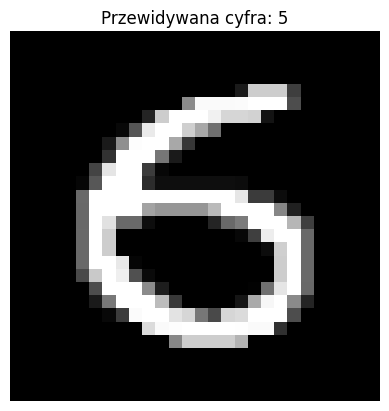

Plik: cyfra_8.png | Model przewidział: 8


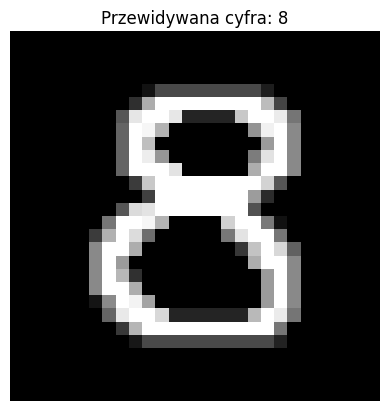

Plik: cyfra_9.png | Model przewidział: 8


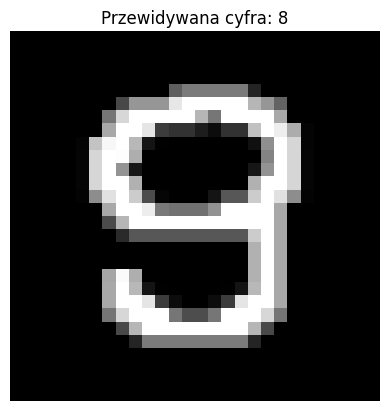

In [6]:
import numpy as np
import tensorflow as tf

import  cv2

import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

#--------------------
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised = True)

mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples=0.9 * mnist_info.splits['train'].num_examples


num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples

num_test_samples = tf.cast(num_test_samples, tf.int64)
#--------------------

def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /=255.
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)
#--------------------

BUFFER_SIZE = 1000

shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)
#--------------------

BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)

validation_data = validation_data.batch(num_validation_samples)

test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

#--------------------
input_size = 784
output_size = 10

#hidden_layer_size = 50
hidden_layer_size = 256

"""
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])"""

model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(output_size, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#--------------------
#NUM_EPOCHS = 5
NUM_EPOCHS = 10
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose = 1
)


#--------------------
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss : {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))
#--------------------

cyfry = ['cyfra_6.png', 'cyfra_8.png', 'cyfra_9.png']

for cyfra in cyfry:
    custom_image = cv2.imread(cyfra, cv2.IMREAD_GRAYSCALE)

    if custom_image is None:
        print(f"BŁĄD: Nie można wczytać pliku {cyfra}")
        continue

    if np.mean(custom_image) > 127:
        tryb = cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    else:
        tryb = cv2.THRESH_BINARY + cv2.THRESH_OTSU

    _, custom_image = cv2.threshold(custom_image, 0, 255, tryb)

    x, y, w, h = cv2.boundingRect(cv2.findNonZero(custom_image))
    custom_image = custom_image[y:y+h, x:x+w]
    pad = max(w, h) // 4
    custom_image = cv2.copyMakeBorder(custom_image, pad, pad, pad, pad, cv2.BORDER_CONSTANT)

    custom_image = cv2.resize(custom_image, (28, 28)).astype(np.float32) / 255.0
    img_reshaped = np.reshape(custom_image, (1, 28, 28, 1))

    prediction = model.predict(img_reshaped, verbose=0)
    predicted_digit = np.argmax(prediction)

    print("="*50)
    print(f"Plik: {cyfra} | Model przewidział: {predicted_digit}")
    print("="*50)

    plt.imshow(custom_image, cmap='gray')
    plt.title(f'Przewidywana cyfra: {predicted_digit}')
    plt.axis('off')
    plt.show()

#--------------------


Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9174 - loss: 0.2725 - val_accuracy: 0.9625 - val_loss: 0.1207
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9694 - loss: 0.1038 - val_accuracy: 0.9855 - val_loss: 0.0616
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9766 - loss: 0.0798 - val_accuracy: 0.9827 - val_loss: 0.0736
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9808 - loss: 0.0660 - val_accuracy: 0.9858 - val_loss: 0.0650
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9841 - loss: 0.0541 - val_accuracy: 0.9890 - val_loss: 0.0542
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9890 - val_loss: 0.0494
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9870 - loss: 0.0420 - val_accuracy: 0.9897 - val_loss: 0.0472
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9889 - loss: 0.0375 - val_accuracy: 

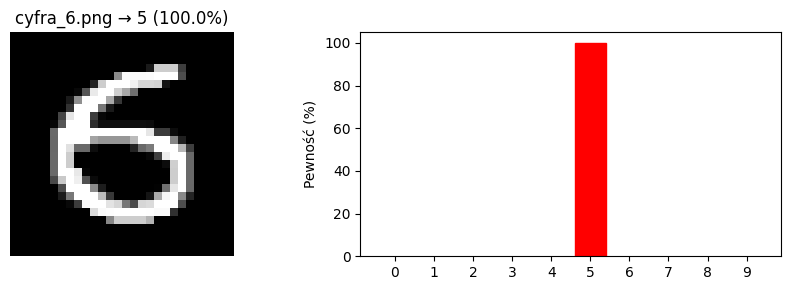

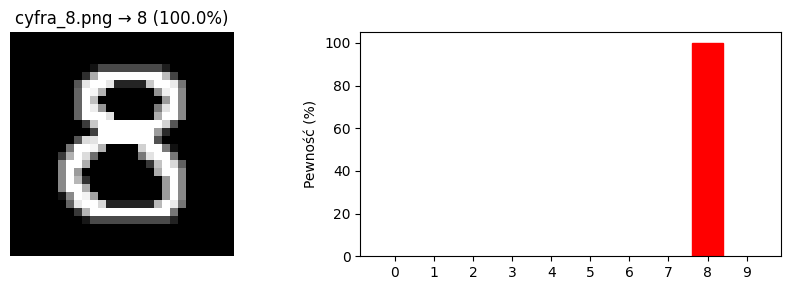

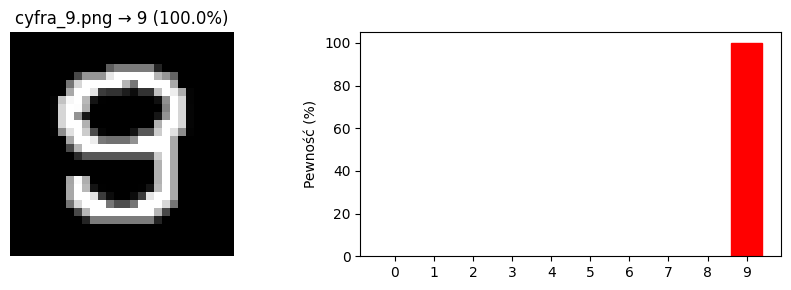

In [5]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

# --- Dane ---
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_val  = tf.cast(0.1 * mnist_info.splits['train'].num_examples, tf.int64)
num_test = tf.cast(mnist_info.splits['test'].num_examples, tf.int64)

def scale(image, label):
    return tf.cast(image, tf.float32) / 255., label

shuffled        = mnist_train.map(scale).shuffle(1000)
validation_data = shuffled.take(num_val).batch(num_val)
train_data      = shuffled.skip(num_val).batch(100)
test_data       = mnist_test.map(scale).batch(num_test)

validation_inputs, validation_targets = next(iter(validation_data))

# --- Model ---
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(train_data, epochs=10,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
          validation_data=(validation_inputs, validation_targets))

test_loss, test_acc = model.evaluate(test_data)
print(f'Test accuracy: {test_acc*100:.2f}%')

def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Błąd: {path}"); return None

    if np.mean(img) > 127:
        tryb = cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    else:
        tryb = cv2.THRESH_BINARY + cv2.THRESH_OTSU

    _, img = cv2.threshold(img, 0, 255, tryb)

    x, y, w, h = cv2.boundingRect(cv2.findNonZero(img))
    img = img[y:y+h, x:x+w]
    pad = max(w, h) // 4
    img = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_CONSTANT)
    img = cv2.resize(img, (28, 28)).astype(np.float32) / 255.
    return img.reshape(1, 28, 28, 1)

# --- Predykcja z wykresem ---
for path in ['cyfra_6.png', 'cyfra_8.png', 'cyfra_9.png']:
    img = preprocess(path)
    if img is None: continue
    probs = model.predict(img, verbose=0)[0]
    pred  = np.argmax(probs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
    ax1.imshow(img.reshape(28, 28), cmap='gray'); ax1.axis('off')
    ax1.set_title(f'{path} → {pred} ({probs[pred]*100:.1f}%)')
    bars = ax2.bar(range(10), probs*100, color='steelblue')
    bars[pred].set_color('red')
    ax2.set_xticks(range(10)); ax2.set_ylabel('Pewność (%)')
    plt.tight_layout(); plt.show()